# IMF sampling with constraints on the mass of the most massive star in the cluster

This code provided in this notebook makes it possible to generate IMF samples from a canonical as well as a varying stellar IMF form, using a modification of the Optimal sampling algorithm.\
I suggest reading _IMF_sampling.ipynb_ and the supplementary document for more in-detail information.

Optimal sampling is a deterministic method of generating data that follow a pre-defined distribution function closely while fulfilling boundary conditions on the generated sample, such as e.g. the total sum of all data points. From its general logic it is closely related to quantile-based sampling methods but has the advantage that no renormalization of the data is needed to fulfill the given boundary conditions, which can lead to the data sample deviating slightly from the aimed at distribution function.\
Optimal sampling combines the fulfillment of boundary conditions with the data following the given distribution function as close as possible by design.

This newly developed algorithm allows using optimal sampling to sample IMFs but giving a most massive stellar as input.\
This allows to easily use empirical relations between cluster mass and most massive stellar mass, the $m_{\mathrm{max}}-M_{\mathrm{ecl}}$ relation.\
This can be used e.g. to generate samples for dynamical simulations and generate IMF samples without random scatter.

Note that this code can generate custom stellar IMFs as well as custom composite IMFs.\
A **stellar IMF** is a special type of IMF. It describes the stellar population of a single embedded cluster, born from one molecular cloud clump. \
This is opposed to a **composite IMF (cIMF)** which describes a stellar population that consists of stars from various embedded clusters. An example for a composite IMF is the Salpeter IMF, that describes the IMF of stars in the Solar neighborhood, independent of whether the stars were all birthed in the same star cluster.\
The composite IMF of a whole galaxy is called **galaxy-wide IMF (gwIMF)**.

Another main aim of this algorithm is to give a possible starting point towards the development of a sub-galactic extension of the IGIMF theory, on which the [galIMF](https://github.com/Azeret/galIMF) module is based.\
The algorithm allows to investigate variations of the $m_{\mathrm{max}}-M_{\mathrm{ecl}}$ relation with environmental conditions (metallicity, density , local SFR...) and subsequently how this may affect the form of cIMFs within star-forming regions. It is necessary to understand this relation very well in order to construct a self-consistent extension of the IGIMF theory towards the sub-galactic scale.

The mathematics within this notebook as well as the main part of the code, containing the modification of the Optimal sampling algorithm, were all developed independently. The Optimal sampling algorithm as used in the galIMF module ([Yan et al. 2017](https://www.aanda.org/articles/aa/full_html/2017/11/aa30987-17/aa30987-17.html)), which can be found on GitHub under https://github.com/Azeret/galIMF, was used as the basis for the development. Some functions within this notebook stem from the galIMF module. Those instances are indicated within the text. 

## Notation

In order to avoid confusion, the valid notation within the rest of the notebook is listed here:
- $M_1$: Mass of the most massive star within the cluster. This is what is referred to as $m_{\mathrm{max}}$ within the $m_{\mathrm{max}}-M_{\mathrm{ecl}}$ relation
- $M_{\mathrm{max}}$, m_max: Upper integration limit for the most massive star in the cluster. Has no physical meaning
- $M_{\mathrm{ecl}}$: Stellar mass of the embedded (star) cluster

Within the codes, $M_{\mathrm{max}}$ is referred to as **m_max** for better distinction between integration limits (small m) and physical values (large M), but referred to as $M_{\mathrm{max}}$ within the text.

## Some necessary functions

First, some functions are defined that are always needed when aiming to optimally sample (varying) stellar IMFs.
Those functions are exactly the same as in _IMF_sampling.ipynb_. 

The function **model_IMF_m** defines the analytical function $\xi(m)\times m$ and is needed to determine the stellar masses.

The functions **function_alpha_i_change**, with i={1,2,3} stem directly from the galIMF source code and are used to define the form of the IMF.

In [1]:
from scipy.optimize import root_scalar
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.integrate

### Drawing from the IMF using the drawn cluster masses M_i

### function alpha_1_change(alpha_1, alpha1_model, M_over_H) imported from galimf.py
def function_alpha_1_change(alpha1_model, M_over_H):
    alpha_1 = 1.3
    if (alpha1_model == 0):
        return alpha_1
    elif (alpha1_model == 1):
        alpha_1_change = alpha_1 + 0.5 * M_over_H
        return alpha_1_change
    elif (alpha1_model == 'IGIMF2.5'):
        alpha_1_change = alpha_1 + 0.12 * M_over_H
        return alpha_1_change
    elif (alpha1_model == 'Z_MW'):
        alpha_1_change = alpha_1 + 79.4 * (10**M_over_H - 10**(-0.1)) * 0.0142
        return alpha_1_change
    elif (alpha1_model == 'Z'):
        alpha_1_change = alpha_1 + 63 * (10**M_over_H - 1) * 0.0142
        return alpha_1_change
    else:
        print('Invalid Input for alpha1 model')
        return

## Function to change alpha_2 depending on the model; imported from galimf.py
def function_alpha_2_change(alpha2_model, M_over_H):
    alpha_2=2.3
    if (alpha2_model == 0):
        return alpha_2
    elif (alpha2_model == 1):
        alpha_2_change = alpha_2 + 0.5 * M_over_H
        return alpha_2_change
    elif (alpha2_model == 'Z_MW'):
        alpha_2_change = alpha_2 + 79.4 * (10**M_over_H - 10**(-0.1)) * 0.0142
        if M_over_H>1:
            print("Warning: Abnormally high gas metallicity leading to an unrealistic IMF shape according to the assumed variation law: alpha2_model == 'Z'. Please check your galaxy evolution settings or change to a different IMF variation assumption.")
        return alpha_2_change
    elif (alpha2_model == 'Z'):
        alpha_2_change = alpha_2 + 63 * (10**M_over_H - 1) * 0.0142
        if M_over_H>1:
            print("Warning: Abnormally high gas metallicity leading to an unrealistic IMF shape according to the assumed variation law: alpha2_model == 'Z'. Please check your galaxy evolution settings or change to a different IMF variation assumption.")
        return alpha_2_change
    elif (alpha2_model == 'IGIMF2.5'):
        alpha_2_change = alpha_2 + 0.12 * M_over_H
        return alpha_2_change
    elif (alpha2_model == 'R14'):
        alpha_2_change = 2.3 + 0.0572 * M_over_H
        return alpha_2_change
    else:
        print('Invalid input for alpha2 model')
        return

## Function to change alpha_3 depending on the model; imported from galimf.py
def function_alpha_3_change(alpha3_model, M_ecl, M_over_H):
    ## M_ecl is the mass of the cluster
    ## M_over_H is the metallicity of the cluster, but apparently is in reality [Z]
    ## since the formula for model 2 is similar to the formula from Yan et al.(2021)
    ## where [Z] is used, I assume that M_over_H is actually [Z]
    ## alpha3_model is the model for the IMF power-index for M_turn2 < M < M_str_U
    if (alpha3_model == 0):
        default_alpha3 = 2.3
        # print("alpha_3 is set to be a constant: %s, as this is the default alpha_3 value for alpha3_model 0.\nFor more options regarding alpha_3 variation, please check file 'alpha3.py'" % (default_alpha3))
        return default_alpha3
    elif (alpha3_model == 1):
        rho = 10 ** (0.61 * math.log(M_ecl, 10) + 2.85)
        if rho < 9.5 * 10 ** 4:
            alpha_3_change = 2.3
        else:
            alpha_3_change = 1.86 - 0.43 * math.log(rho / 10 ** 6, 10)
        # print("Notification in file 'alpha3_model' uncompleted")
        if alpha_3_change < 0.5:
            print("IMF alpha_3 being", alpha_3_change, "out of the tested range from Marks et al. 2012.")
        return alpha_3_change
    elif (alpha3_model == 2):
        rho = 10 ** (0.61 * math.log(M_ecl, 10) + 2.85)
        x = -0.14 * M_over_H + 0.99 * math.log(rho / 10 ** 6, 10)
        if x < -0.87:
            alpha_3_change = 2.3
        else:
            alpha_3_change = -0.41 * x + 1.94
        # print("Notification in file 'alpha3_model' uncompleted")
        return alpha_3_change
    elif (alpha3_model == 'R14'):
        alpha_3_change = 2.3 + 0.0572 * M_over_H
        return alpha_3_change
    else:
        print('Invalid input for alpha_3 model')
        return alpha3_model

## IMF function*m with prefactor. Can be used to determine Masses M_i
def model_IMF_m(m, alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3):
    M_str_L = 0.08  # star mass lower limit [solar mass]
    M_str_U = 150.0  # star mass upper limit [solar mass]
    M_turn = 0.5  # IMF power-index breaking mass [solar mass]
    M_turn2 = 1.  # IMF power-index breaking mass [solar mass]

    alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
    alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
    alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H) #IMF power-index for M_turn2 < M < M_str_U

    ## distinction between cases; IMF is three-part power-law
    if m < M_str_L:
        return 0
    if M_str_L < m < M_turn:
        ### becomes relevant when M_turn and M_turn_2 take different values
        #k1 = M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2)*k3 
        ### When M_turn=0.5 and M_turn2=1.0, k1 simplifies to:
        ###k1= 2.0*k3 ## No! This is only correct, when alpha_1=1.3, alpha_2=2.3 and alpha_3=2.3
        k1=M_turn**(alpha_1-alpha_2)*k3

        return k1 * m**(1-alpha_1)
    if M_turn < m < M_turn2:
        ### becomes relevant when M_turn and M_turn_2 take different values
        #k2 = M_turn2**(alpha_2-alpha_3)*k3 
        ### When M_turn=0.5 and M_turn2=1.0, k2 simplifies to:
        k2= 1.0*k3 ## k2=k3
        return k2 * m**(1-alpha_2)
    if M_turn2 < m < M_str_U:
        return k3*m**(1-alpha_3) ##
    if m > M_str_U:
        return 0

## Finding the $M_{\mathrm{max}}$ value

Since the aim is to give the mass of the most massive star $M_1$ as an input to sample the cluster's IMF, one needs to redefine the way the upper integration limit of the IMF $M_{\mathrm{max}}$ is determined.

$M_{\mathrm{max}}$ (which is not equal to the physical limit, which is $M_U=150\,M_{\odot}$!) is found numerically via the functions **find_m_max_empirical_i**, with i={1,2,3,4,5}, that are defined in the following. In order to determine $M_{\mathrm{max}}$ the cluster mass $M_\mathrm{ecl}$, the mass of the most massive star in the cluster $M_1$ and IMF model are needed as input. 

## Derivations

In the following, the equation system needed to be solved to find $M_{\mathrm{max}}$ is determined for every possible case that might occur.\
In all cases it is assumed that $\alpha_1,\alpha_2,\alpha_3 \neq 1$ and $\alpha_1,\alpha_2,\alpha_3 \neq 2$.

### $M_{\mathrm{turn},2} < m_2, M_{\mathrm{max}}$

Assume that there is exactly 1 star in the mass range $[m_2,M_{\mathrm{max}}]$:
\begin{eqnarray*}
	1&=&\int^{M_{\mathrm{max}}}_{m_2}k_3 m^{-\alpha_3}dm=\frac{k_3}{1-\alpha_3}\cdot(M_{\mathrm{max}}^{1-\alpha_3}-m_{2}^{1-\alpha_3})\\
	\Leftrightarrow \frac{1-\alpha_3}{k_3}&=&M_{\mathrm{max}}^{1-\alpha_3}-m_{2}^{1-\alpha_3}\\
	\Leftrightarrow m_{2}^{1-\alpha_3}&=&M_{\mathrm{max}}^{1-\alpha_3}-\frac{1-\alpha_3}{k_3}
\end{eqnarray*}
\begin{equation}
	\Rightarrow m_2=(M_{\mathrm{max}}^{1-\alpha_3}-\frac{1-\alpha_3}{k_3})^{\frac{1}{1-\alpha_3}} \quad \mathrm{and\ also} \quad m_{i+1}=(m_i^{1-\alpha_3}-\frac{1-\alpha_3}{k_3})^{\frac{1}{1-\alpha_3}}
\end{equation} 

 
Further, the mass of the most massive star is 
\begin{align*}
M_1=\int_{m_2}^{M_{\mathrm{max}}}\xi(m)\cdot m \, \mathrm{d}m=k_3 \int_{m_2}^{M_{\mathrm{max}}}m^{1-\alpha_3} \, \mathrm{d}m = \frac{k_3}{2-\alpha_3}(M_{max}^{2-\alpha_3}-m_2^{2-\alpha_3})
\end{align*}


Assume that we have given the mass of the most massive star $M_1$ and the mass of the cluster $M_{\mathrm{ecl}}$. The following two equations have to hold true. First, since $M_1$ is assumed to be known one can follow from this that

\begin{eqnarray*} 
	M_1 &=& \int^{M_{\mathrm{max}}}_{m_2}k_3m^{1-\alpha_3}dm\stackrel{\alpha_3 \neq 2}{=}\frac{k_3}{2-\alpha_3}(M_{\mathrm{max}}^{2-\alpha_3}-m_2^{2-\alpha_3})\\
	& \Leftrightarrow & \frac{2-\alpha_3}{k_3}M_1= M_{\mathrm{max}}^{2-\alpha_3}-m_2^{2-\alpha_3}\\
	& \Leftrightarrow & m_2^{2-\alpha_3}=  M_{\mathrm{max}}^{2-\alpha_3}-\frac{2-\alpha_3}{k_3}M_1 
\end{eqnarray*}
\begin{equation}
	\Rightarrow m_2=(M_{\mathrm{max}}^{2-\alpha_3}-\frac{2-\alpha_3}{k_3}M_1)^{\frac{1}{2-\alpha_3}} \\
\end{equation}

Also, we know that the total mass of the cluster $M_{\mathrm{ecl}}$ has to be

\begin{align*}
	M_{\mathrm{ecl}} &=&\int^{M_{\mathrm{turn}}}_{M_{L}}k_1m^{1-\alpha_1}dm+\int^{M_{\mathrm{turn,2}}}_{M_{turn}}k_2m^{1-\alpha_2}dm+\int^{M_{\mathrm{max}}}_{M_{turn,2}}k_3m^{1-\alpha_3}dm\\
    &=& \frac{k_1}{2-\alpha_1}(M_{\mathrm{turn}}^{2-\alpha_1}-M_L^{2-\alpha_1})+\frac{k_2}{2-\alpha_2}(M_{\mathrm{turn,2}}^{2-\alpha_2}-M_{\mathrm{turn}}^{2-\alpha_2})+\frac{k_3}{2-\alpha_3}(M_{\mathrm{max}}^{2-\alpha_3}-M_\mathrm{turn,2}^{2-\alpha_3})\\
    &=& \frac{k_3M_{\mathrm{turn,2}}^{\alpha_2-\alpha_3}M_{\mathrm{turn}}^{\alpha_1-\alpha_2}}{2-\alpha_1}(M_{\mathrm{turn}}^{2-\alpha_1}-M_L^{2-\alpha_1})+\frac{k_3M_{\mathrm{turn,2}}^{\alpha_2-\alpha_3}}{2-\alpha_2}(M_{\mathrm{turn,2}}^{2-\alpha_2}-M_{\mathrm{turn}}^{2-\alpha_2})+ \frac{k_3}{2-\alpha_3}\cdot(M_{\mathrm{max}}^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3})\\
    &=& k_3[\frac{M_{\mathrm{turn,2}}^{\alpha_2-\alpha_3}M_{\mathrm{turn}}^{\alpha_1-\alpha_2}}{2-\alpha_1}(M_{\mathrm{turn}}^{2-\alpha_1}-M_L^{2-\alpha_1})+\frac{M_{\mathrm{turn,2}}^{\alpha_2-\alpha_3}}{2-\alpha_2}(M_{\mathrm{turn,2}}^{2-\alpha_2}-M_{\mathrm{turn}}^{2-\alpha_2})+ \frac{1}{2-\alpha_3}\cdot(M_{\mathrm{max}}^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3})]
\end{align*}
\begin{equation}
	\Rightarrow k_3=M_{\mathrm{ecl}}[\frac{M_{\mathrm{turn,2}}^{\alpha_2-\alpha_3}M_{\mathrm{turn}}^{\alpha_1-\alpha_2}}{2-\alpha_1}(M_{\mathrm{turn}}^{2-\alpha_1}-M_L^{2-\alpha_1})+\frac{M_{\mathrm{turn,2}}^{\alpha_2-\alpha_3}}{2-\alpha_2}(M_{\mathrm{turn,2}}^{2-\alpha_2}-M_{\mathrm{turn}}^{2-\alpha_2})+ \frac{1}{2-\alpha_3}\cdot(M_{\mathrm{max}}^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3})]^{-1}
\end{equation}

$M_{L}$ here refers to the lower physical limit of stellar masses and is typically set to $M_{L,\mathrm{ecl}}=0.8\,M_{\odot}$ and $M_{turn}=0.5\,M_{\odot}$, $M_{turn,2}=1\,M_{\odot}$ refers to the masses, where the IMF slope changes.\\

Setting both equation for $m_2$ equal yields
\begin{equation*}
(M_{\mathrm{max}}^{2-\alpha_3}-\frac{2-\alpha_3}{k_3}M_1)^{\frac{1}{2-\alpha_3}} = (M_{\mathrm{max}}^{1-\alpha_3}-\frac{1-\alpha_3}{k_3})^{\frac{1}{1-\alpha_3}}
\end{equation*}
Since an expression for $k_3$ is known, the final equation in simplified form is
\begin{equation}
(M_{\mathrm{max}}^{2-\alpha_3}-\frac{2-\alpha_3}{k_3}M_1) = (M_{\mathrm{max}}^{1-\alpha_3}-\frac{1-\alpha_3}{k_3})^{\frac{2-\alpha_3}{1-\alpha_3}}
\end{equation}

This equation has to be solved numerically for $M_{\mathrm{max}}$ and all other integration bounds can be determined as for the usual optimal sampling algorithm.

In [2]:
## M_max_finder case 1. Covers most cases with Mecl > 5 solar masses

def find_m_max_empirical(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
    M_str_L = 0.08  # star mass lower limit [solar mass]
    M_str_U = 150.0  # star mass upper limit [solar mass]
    M_turn = 0.5  # IMF power-index breaking mass [solar mass]
    M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]

    alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
    alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
    alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U

    def Max(M_max):
        eq1 = M_max**(2-alpha_3)-(2-alpha_3)*M_1/(M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(M_max**(2-alpha_3)-M_turn2**(2-alpha_3))))
        eq2 = (M_max**(1-alpha_3)-(1-alpha_3)/(M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(M_max**(2-alpha_3)-M_turn2**(2-alpha_3)))))**((2-alpha_3)/(1-alpha_3)) 
        return eq1 - eq2

    ### If root-solving does not converge, give out some m_max value M_turn < m_max < M_turn2. Here, I chose 0.9.
    try:
        sol = root_scalar(Max, bracket=[M_turn2, 0.999999*M_str_U])
        M_max = sol.root
        return M_max
    except ValueError:
        return 0.9

### $m_2 < M_{\mathrm{turn},2} < M_{\mathrm{max}}$

Assume that there is exactly 1 star in the mass range $[m_2,M_{\mathrm{max}}]$:
\begin{eqnarray*}
	1&=&\int^{M_{\mathrm{turn,2}}}_{m_2}k_2m^{-\alpha_2}dm + \int^{M_{\mathrm{max}}}_{M_{\mathrm{turn,2}}}k_3 m^{-\alpha_3}dm=\frac{k_2}{1-\alpha_2}\cdot(M_{\mathrm{turn,2}}^{1-\alpha_2}-m_{2}^{1-\alpha_2}) + \frac{k_3}{1-\alpha_3}\cdot(M_{\mathrm{max}}^{1-\alpha_3}-M_{\mathrm{turn,2}}^{1-\alpha_3})\\
	\Leftrightarrow M_{\mathrm{turn,2}}^{1-\alpha_2}-m_{2}^{1-\alpha_2} &=& \frac{1-\alpha_2}{k_2}(1-\frac{k_3}{1-\alpha_3}\cdot(M_{\mathrm{max}}^{1-\alpha_3}-M_{\mathrm{turn,2}}^{1-\alpha_3}))\\
	\Leftrightarrow m_{2}^{1-\alpha_2}&=& M_{\mathrm{turn,2}}^{1-\alpha_2} - \frac{1-\alpha_2}{k_2}(1-\frac{k_3}{1-\alpha_3}\cdot(M_{\mathrm{max}}^{1-\alpha_3}-M_{\mathrm{turn,2}}^{1-\alpha_3}))\\
    \Leftrightarrow m_2&=&(M_{\mathrm{turn,2}}^{1-\alpha_2} - \frac{1-\alpha_2}{k_2}(1-\frac{k_3}{1-\alpha_3}\cdot(M_{\mathrm{max}}^{1-\alpha_3}-M_{\mathrm{turn,2}}^{1-\alpha_3})))^{\frac{1}{1-\alpha_2}}\\
    \Leftrightarrow m_2&=&(M_{\mathrm{turn,2}}^{1-\alpha_2} + \frac{k_3}{k_2}\frac{1-\alpha_2}{1-\alpha_3}(M_{\mathrm{max}}^{1-\alpha_3}-M_{\mathrm{turn,2}}^{1-\alpha_3}) - \frac{1-\alpha_2}{k_2})^{\frac{1}{1-\alpha_2}}\\
    \Rightarrow m_2&\stackrel{k_3=k_2M_{\mathrm{turn,2}}^{\alpha_3-\alpha_2}}{=}&(M_{\mathrm{turn,2}}^{1-\alpha_2} + M_{\mathrm{turn,2}}^{\alpha_3-\alpha_2}\frac{1-\alpha_2}{1-\alpha_3}(M_{\mathrm{max}}^{1-\alpha_3}-M_{\mathrm{turn,2}}^{1-\alpha_3}) - \frac{1-\alpha_2}{k_2})^{\frac{1}{1-\alpha_2}} \quad \mathrm{and\ also} \quad m_{i+1}=(M_{\mathrm{turn,2}}^{1-\alpha_2} + M_{\mathrm{turn,2}}^{\alpha_3-\alpha_2}\frac{1-\alpha_2}{1-\alpha_3}(m_i^{1-\alpha_3}-M_{\mathrm{turn,2}}^{1-\alpha_3}) - \frac{1-\alpha_2}{k_2})^{\frac{1}{1-\alpha_2}}
\end{eqnarray*}

The mass of the most massive star is 
\begin{eqnarray*}
M_1&=&\int_{m_2}^{M_{\mathrm{max}}}\xi(m)\cdot m \, \mathrm{d}m=\int^{M_{\mathrm{turn,2}}}_{m_2}k_2m^{1-\alpha_2}dm + \int^{M_{\mathrm{max}}}_{M_{\mathrm{turn,2}}}k_3 m^{1-\alpha_3}dm = \frac{k_2}{2-\alpha_2}\cdot(M_{\mathrm{turn,2}}^{2-\alpha_2}-m_{2}^{2-\alpha_2}) + \frac{k_3}{2-\alpha_3}\cdot(M_{\mathrm{max}}^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3}) \\
\Leftrightarrow M_{\mathrm{turn,2}}^{2-\alpha_2}-m_{2}^{2-\alpha_2}  &=& \frac{2-\alpha_2}{k_2}(M_1 -\frac{k_3}{2-\alpha_3}\cdot(M_{\mathrm{max}}^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3})) \\
\Leftrightarrow m_{2}^{2-\alpha_2} &=& M_{\mathrm{turn,2}}^{2-\alpha_2} - \frac{2-\alpha_2}{k_2}(M_1 -\frac{k_3}{2-\alpha_3}\cdot(M_{\mathrm{max}}^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3}))\\
\Leftrightarrow m_2 &=&  (M_{\mathrm{turn,2}}^{2-\alpha_2} - \frac{2-\alpha_2}{k_2}(M_1 -\frac{k_3}{2-\alpha_3}\cdot(M_{\mathrm{max}}^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3})))^{\frac{1}{2-\alpha_2}}\\
\Leftrightarrow m_2 &=& (M_{\mathrm{turn,2}}^{2-\alpha_2} + \frac{k_3}{k_2}\frac{2-\alpha_2}{2-\alpha_3}(M_{\mathrm{max}}^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3}) - \frac{2-\alpha_2}{k_2}M_1 )^{\frac{1}{2-\alpha_2}}\\
\Rightarrow m_2 &\stackrel{k_3=k_2M_{\mathrm{turn,2}}^{\alpha_3-\alpha_2}}{=}& (M_{\mathrm{turn,2}}^{2-\alpha_2} + M_{\mathrm{turn,2}}^{\alpha_3-\alpha_2}\frac{2-\alpha_2}{2-\alpha_3}(M_{\mathrm{max}}^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3}) - \frac{2-\alpha_2}{k_2}M_1 )^{\frac{1}{2-\alpha_2}} \quad \mathrm{and\ also} \quad m_{i+1} = (M_{\mathrm{turn,2}}^{2-\alpha_2} + M_{\mathrm{turn,2}}^{\alpha_3-\alpha_2}\frac{2-\alpha_2}{2-\alpha_3}(m_i^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3}) - \frac{2-\alpha_2}{k_2}M_1 )^{\frac{1}{2-\alpha_2}}
\end{eqnarray*}

Since $M_{\mathrm{max}}>M_{\mathrm{turn,2}}$, the same $k_3=$ as before applies in this case and using $k_2=k_3M_{\mathrm{turn,2}}^{\alpha_2-\alpha_3}$ the final equation becomes

\begin{eqnarray*}
    (M_{\mathrm{turn,2}}^{2-\alpha_2} + M_{\mathrm{turn,2}}^{\alpha_3-\alpha_2}\frac{2-\alpha_2}{2-\alpha_3}(M_{\mathrm{max}}^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3}) - \frac{2-\alpha_2}{k_3M_{\mathrm{turn,2}}^{\alpha_2-\alpha_3}}M_1 )^{\frac{1}{2-\alpha_2}} &=&  (M_{\mathrm{turn,2}}^{1-\alpha_2} + M_{\mathrm{turn,2}}^{\alpha_3-\alpha_2}\frac{1-\alpha_2}{1-\alpha_3}(M_{\mathrm{max}}^{1-\alpha_3}-M_{\mathrm{turn,2}}^{1-\alpha_3}) - \frac{1-\alpha_2}{k_3M_{\mathrm{turn,2}}^{\alpha_2-\alpha_3}})^{\frac{1}{1-\alpha_2}}\\
    \Rightarrow M_{\mathrm{turn,2}}^{2-\alpha_2} + M_{\mathrm{turn,2}}^{\alpha_3-\alpha_2}\frac{2-\alpha_2}{2-\alpha_3}(M_{\mathrm{max}}^{2-\alpha_3}-M_{\mathrm{turn,2}}^{2-\alpha_3}) - \frac{2-\alpha_2}{k_3M_{\mathrm{turn,2}}^{\alpha_2-\alpha_3}}M_1 &=& (M_{\mathrm{turn,2}}^{1-\alpha_2} + M_{\mathrm{turn,2}}^{\alpha_3-\alpha_2}\frac{1-\alpha_2}{1-\alpha_3}(M_{\mathrm{max}}^{1-\alpha_3}-M_{\mathrm{turn,2}}^{1-\alpha_3}) - \frac{1-\alpha_2}{k_3M_{\mathrm{turn,2}}^{\alpha_2-\alpha_3}})^{\frac{2-\alpha_2}{1-\alpha_2}} 
\end{eqnarray*}

In [3]:
## M_max_finder case 2

def find_m_max_empirical_2(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
    M_str_L = 0.08  # star mass lower limit [solar mass]
    M_str_U = 150.0  # star mass upper limit [solar mass]
    M_turn = 0.5  # IMF power-index breaking mass [solar mass]
    M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]

    alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
    alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
    alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U

    def Max(M_max):
        eq1 = M_turn2**(2-alpha_2)+M_turn2**(alpha_3-alpha_2)*(2-alpha_2)/(2-alpha_3)*(M_max**(2-alpha_3)-M_turn2**(2-alpha_3))-(2-alpha_2)*M_1/(M_turn2**(alpha_2-alpha_3)*M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(M_max**(2-alpha_3)-M_turn2**(2-alpha_3))))
        eq2 = (M_turn2**(1-alpha_2)+M_turn2**(alpha_3-alpha_2)*(1-alpha_2)/(1-alpha_3)*(M_max**(1-alpha_3)-M_turn2**(1-alpha_3))-(1-alpha_2)/(M_turn2**(alpha_2-alpha_3)*M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(M_max**(2-alpha_3)-M_turn2**(2-alpha_3)))))**((2-alpha_2)/(1-alpha_2)) 
        return eq1 - eq2
    
    sol = root_scalar(Max, bracket=[M_turn2, 0.999999*M_str_U])
    M_max = sol.root
    return M_max

## $M_{\mathrm{turn}} < m_2, M_{\mathrm{max}} < M_{\mathrm{turn},2}$

Analogously, one can determine that the final equation in this case is

\begin{equation}
(M_{\mathrm{max}}^{2-\alpha_2}-\frac{2-\alpha_2}{k_2}M_1) = (M_{\mathrm{max}}^{1-\alpha_2}-\frac{1-\alpha_2}{k_2})^{\frac{2-\alpha_2}{1-\alpha_2}}
\end{equation}

Since the mass range does not cover the high-mass part anymore, the new $M_{\mathrm{ecl}}$ becomes 

\begin{align*}
	M_{\mathrm{ecl}} &=&\int^{M_{\mathrm{turn}}}_{M_{L}}k_1m^{1-\alpha_1}dm+\int^{M_{\mathrm{max}}}_{M_{turn}}k_2m^{1-\alpha_2}dm\\
    &=& \frac{k_1}{2-\alpha_1}(M_{\mathrm{turn}}^{2-\alpha_1}-M_L^{2-\alpha_1})+\frac{k_2}{2-\alpha_2}(M_{\mathrm{max}}^{2-\alpha_2}-M_{\mathrm{turn}}^{2-\alpha_2})\\
    &=& \frac{k_2M_{\mathrm{turn}}^{\alpha_1-\alpha_2}}{2-\alpha_1}(M_{\mathrm{turn}}^{2-\alpha_1}-M_L^{2-\alpha_1})+\frac{k_2}{2-\alpha_2}(M_{\mathrm{max}}^{2-\alpha_2}-M_{\mathrm{turn}}^{2-\alpha_2})\\
    &=& k_3[\frac{M_{\mathrm{turn}}^{\alpha_1-\alpha_2}}{2-\alpha_1}(M_{\mathrm{turn}}^{2-\alpha_1}-M_L^{2-\alpha_1})+\frac{1}{2-\alpha_2}(M_{\mathrm{max}}^{2-\alpha_2}-M_{\mathrm{turn}}^{2-\alpha_2})]
\end{align*}
\begin{equation}
	\Rightarrow k_2=M_{\mathrm{ecl}}[\frac{M_{\mathrm{turn}}^{\alpha_1-\alpha_2}}{2-\alpha_1}(M_{\mathrm{turn}}^{2-\alpha_1}-M_L^{2-\alpha_1})+\frac{1}{2-\alpha_2}(M_{\mathrm{max}}^{2-\alpha_2}-M_{\mathrm{turn}}^{2-\alpha_2})]^{-1}
\end{equation}

In [4]:
## M_max_finder case 3

def find_m_max_empirical_3(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
    M_str_L = 0.08  # star mass lower limit [solar mass]
    M_str_U = 150.0  # star mass upper limit [solar mass]
    M_turn = 0.5  # IMF power-index breaking mass [solar mass]
    M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]

    alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
    alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
    alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U

    def Max(M_max):
        eq1 = M_max**(2-alpha_2)-(2-alpha_2)*M_1/(M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (M_max**(2-alpha_2) - M_turn**(2-alpha_2))))
        eq2 = (M_max**(1-alpha_2)-(1-alpha_2)/(M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (M_max**(2-alpha_2) - M_turn**(2-alpha_2)))))**((2-alpha_2)/(1-alpha_2)) 
        return eq1 - eq2

    ### If root-solving does not converge, give out some m_max value with m_max < M_turn2. Here, I chose 0.4.
    try:
        sol = root_scalar(Max, bracket=[M_turn, 0.999999*M_turn2])
        M_max = sol.root
        return M_max
    except ValueError:
        return 0.4

## $m_2 < M_{\mathrm{turn}} < M_{\mathrm{max}} < M_{\mathrm{turn},2}$

Again analagous to before, and using $k_1=k_2M_{\mathrm{turn}}^{\alpha_1-\alpha_2}$ or $k_2=k_1M_{\mathrm{turn}}^{\alpha_2-\alpha_1}$ respectively, the final equation becomes

\begin{eqnarray*}
    (M_{\mathrm{turn}}^{2-\alpha_1} + \frac{k_2}{k_1}\frac{2-\alpha_1}{2-\alpha_2}(M_{\mathrm{max}}^{2-\alpha_2}-M_{\mathrm{turn}}^{2-\alpha_2}) - \frac{2-\alpha_1}{k_1}M_1 )^{\frac{1}{2-\alpha_1}} &=&  (M_{\mathrm{turn}}^{1-\alpha_1} + \frac{k_2}{k_1}\frac{1-\alpha_1}{1-\alpha_2}(M_{\mathrm{max}}^{1-\alpha_2}-M_{\mathrm{turn}}^{1-\alpha_2}) - \frac{1-\alpha_1}{k_1})^{\frac{1}{1-\alpha_1}}\\
    \Leftrightarrow (M_{\mathrm{turn}}^{2-\alpha_1} + M_{\mathrm{turn}}^{\alpha_2-\alpha_1}\frac{2-\alpha_1}{2-\alpha_2}(M_{\mathrm{max}}^{2-\alpha_2}-M_{\mathrm{turn}}^{2-\alpha_2}) - \frac{2-\alpha_1}{k_2M_{\mathrm{turn}}^{\alpha_1-\alpha_2}}M_1 )^{\frac{1}{2-\alpha_1}} &=&  (M_{\mathrm{turn}}^{1-\alpha_1} + M_{\mathrm{turn}}^{\alpha_2-\alpha_1}\frac{1-\alpha_1}{1-\alpha_2}(M_{\mathrm{max}}^{1-\alpha_2}-M_{\mathrm{turn}}^{1-\alpha_2}) - \frac{1-\alpha_1}{k_2M_{\mathrm{turn}}^{\alpha_1-\alpha_2}})^{\frac{1}{1-\alpha_1}}\\
  \Rightarrow  M_{\mathrm{turn}}^{2-\alpha_1} + M_{\mathrm{turn}}^{\alpha_2-\alpha_1}\frac{2-\alpha_1}{2-\alpha_2}(M_{\mathrm{max}}^{2-\alpha_2}-M_{\mathrm{turn}}^{2-\alpha_2}) - \frac{2-\alpha_1}{k_2M_{\mathrm{turn}}^{\alpha_1-\alpha_2}}M_1 &=& (M_{\mathrm{turn}}^{1-\alpha_1} + M_{\mathrm{turn}}^{\alpha_2-\alpha_1}\frac{1-\alpha_1}{1-\alpha_2}(M_{\mathrm{max}}^{1-\alpha_2}-M_{\mathrm{turn}}^{1-\alpha_2}) - \frac{1-\alpha_1}{k_2M_{\mathrm{turn}}^{\alpha_1-\alpha_2}})^{\frac{2-\alpha_1}{1-\alpha_1}} 
\end{eqnarray*}

The same expression for $k_2$ as before can be used again.

In [5]:
## M_max_finder case 4

def find_m_max_empirical_4(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
    M_str_L = 0.08  # star mass lower limit [solar mass]
    M_str_U = 150.0  # star mass upper limit [solar mass]
    M_turn = 0.5  # IMF power-index breaking mass [solar mass]
    M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]

    alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
    alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
    alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U

    def Max(M_max):
        eq1 = M_turn**(2-alpha_1)+M_turn**(alpha_2-alpha_1)*(2-alpha_1)/(2-alpha_2)*(M_max**(2-alpha_2)-M_turn**(2-alpha_2))-(2-alpha_1)*M_1/(M_turn**(alpha_1-alpha_2)*M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (M_max**(2-alpha_2) - M_turn**(2-alpha_2))))
        eq2 = (M_turn**(1-alpha_1)+M_turn**(alpha_2-alpha_1)*(1-alpha_1)/(1-alpha_2)*(M_max**(1-alpha_2)-M_turn**(1-alpha_2))-(1-alpha_1)/(M_turn**(alpha_1-alpha_2)*M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (M_max**(2-alpha_2) - M_turn**(2-alpha_2)))))**((2-alpha_1)/(1-alpha_1)) 
        return eq1 - eq2
    
    sol = root_scalar(Max, bracket=[M_turn, 0.999999*M_turn2])
    M_max = sol.root
    return M_max

## $m_2, M_{\mathrm{max}} < M_{\mathrm{turn}}$

The final equation in the last case is

\begin{equation*}
    (M_{\mathrm{max}}^{2-\alpha_1}-\frac{2-\alpha_1}{k_1}M_1) = (M_{\mathrm{max}}^{1-\alpha_1}-\frac{1-\alpha_1}{k_1})^{\frac{2-\alpha_1}{1-\alpha_1}}
\end{equation*}

Since the mass range does not cover the high-mass part anymore, the new $M_{\mathrm{ecl}}$ becomes 

\begin{align*}
	M_{\mathrm{ecl}} =\int^{M_{\mathrm{max}}}_{M_{L}}k_1m^{1-\alpha_1}dm = \frac{k_1}{2-\alpha_1}(M_{\mathrm{max}}^{2-\alpha_1}-M_L^{2-\alpha_1})\\
\end{align*}
\begin{equation}
	\Rightarrow k_1=M_{\mathrm{ecl}}\frac{2-\alpha_1}{M_{\mathrm{max}}^{2-\alpha_1}-M_L^{2-\alpha_1}}
\end{equation}

In [6]:
## M_max_finder case 5

def find_m_max_empirical_5(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
    M_str_L = 0.08  # star mass lower limit [solar mass]
    M_str_U = 150.0  # star mass upper limit [solar mass]
    M_turn = 0.5  # IMF power-index breaking mass [solar mass]
    M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]

    alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
    alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
    alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U

    def Max(M_max):
        eq1 = M_max**(2-alpha_1)-(2-alpha_1)*M_1/(M_ecl * (2-alpha_1) / (M_max**(2-alpha_1) - M_str_L**(2-alpha_1)))
        eq2 = (M_max**(1-alpha_1)-(1-alpha_1)/(M_ecl * (2-alpha_1) / (M_max**(2-alpha_1) - M_str_L**(2-alpha_1))))**((2-alpha_1)/(1-alpha_1)) 
        return eq1 - eq2

    ### If root-solving does not converge, give out some m_max value with m_max < M_str_L to give out the final error message. Here, I chose 0.07
    try:
        sol = root_scalar(Max, bracket=[0.08+1e-15, 0.999999*M_turn])
        M_max = sol.root
        return M_max
    except ValueError:
        return 0.07

# Sampling function

Finally, the sampling function is defined below. The inputs in order to use it are explained here.

## Inputs for the most important IMF models

There are several IMF models already implemented from which data can be generated using optimal sampling. In order to set a model, the inputs **alpha_i_model**, with i={1,2,3}, need to be defined.

For a canonical IMF, simply use:

alpha_1_model=0 \
alpha_2_model=0 \
alpha_3_model=0

For the varying IMF, typically used within the IGIMF Theory and defined within [Yan et al. (2021)](https://www.aanda.org/articles/aa/full_html/2021/11/aa40683-21/aa40683-21.html) use:

alpha_1_model='Z' \
alpha_2_model='Z' \
alpha_3_model= 2

## Other inputs

In order to generate data, the code further needs the **(embedded) cluster mass $M_{\mathrm{ecl}}$**, the **mass of the most massive star $M_1$** as well as the metallicity **M_over_H** of the molecular cloud in terms of **[Z]** as input. 

$M_{\mathrm{ecl}}$ is equal to the total **stellar** mass formed, i.e. the desired stellar mass formed from the molecular cloud.

The algorithm will return a sample of stellar masses that is as close as possible to $M_{\mathrm{ecl}}$, following the pre-defined IMF.\
The maximum stellar mass within the cluster is almost identical to $M_1$.

In [7]:
### IMF sampling function with most massive stellar mass as input. Can be used with empirical m_max-M_ecl relations.

### Needs mass of the embedded cluster (M_ecl), 
### the mass of the most massive star (M_1),
### the IMF model for the IMF powerlaw indices (alpha_1_model, alpha_2_model, alpha_3_model)
### and the metallicity of the cluster (M_over_H) as input

def draw_imf_empirical(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
    M_str_L = 0.08  # star mass lower limit [solar mass]
    M_str_U = 150.0  # star mass upper limit [solar mass]
    M_turn = 0.5  # IMF power-index breaking mass [solar mass]
    M_turn2 = 1.  # IMF power-index breaking mass [solar mass]

    ## Definition of alpha_1 and alpha_2
    alpha_1=function_alpha_1_change(alpha_1_model, M_over_H) #IMF power-index for M_str_L < M < M_turn
    alpha_2=function_alpha_2_change(alpha_2_model, M_over_H) #IMF power-index for M_turn < M < M_turn2

    ## alpha_3 is assumed to vary with metallicity and cluster mass
    alpha_3=function_alpha_3_change(alpha_3_model, M_ecl, M_over_H) #IMF power-index for M_turn2 < M < M_str_U

    ## Find m_max for a given M_ecl and M_1 by using root_scalar
    ## m_max=m_1 is the upper integration limit for the most massive star in the cluster
    ## It is NOT the mass of the most massive star in the cluster!

    ### m_i and m_i+1 are not the stellar masses, but only the upper and lower limits of the mass intervals
    ### from which the masses M_i are drawn

    # Determine m_max under the assumption M_turn2 < m2, m_max. 
    # This is always true for the canonical IMF if M_ecl > 5 but there may be special cases for other IMF forms or certain cutoffs. 
    m_max=find_m_max_empirical(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
    m_i=m_max
    
    
    ## Determine m_max by going through all cases
    if M_turn2 < m_max < M_str_U:
        k3=M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(m_max**(2-alpha_3)-M_turn2**(2-alpha_3)))
        k1=M_turn**(alpha_1-alpha_2)*k3
        k2=k3
        
        m_i_1=(m_i**(1-alpha_3)-(1-alpha_3)/(k3))**(1/(1-alpha_3)) #Case 1
        print('m2_1=',m_i_1)
    
        ## If m_2 < M_turn, recalculate m_max and m_2. Transition between case 1 and 2 is smooth, as both are equal, when m_2=M_turn2
        if M_turn < m_i_1 < M_turn2:
            m_max=find_m_max_empirical_2(M_ecl, M_1 , alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
            m_i=m_max
            k3=M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(m_max**(2-alpha_3)-M_turn2**(2-alpha_3)))
            k1=M_turn**(alpha_1-alpha_2)*k3
            k2=k3
            m_i_2=(M_turn2**(1-alpha_2)+k3/k2*(1-alpha_2)/(1-alpha_3)*(m_i**(1-alpha_3)-M_turn2**(1-alpha_3))-(1-alpha_2)/k2)**(1/(1-alpha_2)) #Case 2
            print('m2_2=',m_i_2)

    elif m_max < M_turn2:
        ## recalculate the m_max, if it is smaller than M_turn2. Transition between case 1 and 3 is smooth, as both are equal, when m_max=M_turn2
        m_max=find_m_max_empirical_3(M_ecl,M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
        m_i=m_max
        k2=M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (m_max**(2-alpha_2) - M_turn**(2-alpha_2)))
        m_i_3=(m_i**(1-alpha_2)-(1-alpha_2)/k2)**(1/(1-alpha_2))
        print('m2_3=',m_i_3)
        if M_turn < m_max < M_turn2:
            ## Check whether m_2 is larger or smaller than M_turn
            if M_turn < m_i_3 < M_turn2:
                k2=M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (m_max**(2-alpha_2) - M_turn**(2-alpha_2)))
                k1=M_turn**(alpha_1-alpha_2)*k2
                k3=k2
            ## If m_2 < M_turn, recalculate m_max and m_2. Transition between case 3 and 4 is smooth, as both are equal, when m_2=M_turn
            elif m_i_3 < M_turn:
                m_max=find_m_max_empirical_4(M_ecl,M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
                m_i=m_max
                k2=M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (m_max**(2-alpha_2) - M_turn**(2-alpha_2)))
                k1=M_turn**(alpha_1-alpha_2)*k2
                k3=k2
                m_i_4=(M_turn**(1-alpha_1)+k2/k1*(1-alpha_1)/(1-alpha_2)*(m_i**(1-alpha_2)-M_turn**(1-alpha_2))-(1-alpha_1)/k1)**(1/(1-alpha_1))

                print('m2_4', m_i_4)
            
        ## when m_max is smaller than M_turn, the m_max has to be recalculated
        ## transition from case 3 to case 5 is smooth, as both are equal, when m_max=M_turn
        elif m_max < M_turn:
            m_max=find_m_max_empirical_5(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
            m_i=m_max
            k1=M_ecl*(2-alpha_1)/(m_max**(2-alpha_1)-M_str_L**(2-alpha_1))
            k2=M_turn**(alpha_2-alpha_1)*k1
            k3=k2
            m_i_5=(m_i**(1-alpha_1)-(1-alpha_1)/k1)**(1/(1-alpha_1))
            print('m2_5=',m_i_5)
            ### if m_max< M_str_L it is not possible to draw stars
            if m_max < M_str_L:
                print('m_max < M_L. No stars can form')
                return None, None, None, None, None, None, None
    
        ### if m_max cannot be found something went wrong in the calculation of m_max
        else:
            print('m_max could not be found')
            return
        
    
    else:
        print('m_max could not be found')
        return

    ### draw all other stars with the conditions stated in supplementary document
    ### m_i_array is the array of all integration limits for the stars in the cluster
    m_i_array = np.array([])
    m_i_array=np.append(m_i_array,m_i)
    ### Array for all Masses M_i that are drawn with help of the integration limits m_i
    M_i_array = np.array([])
    ### Masses M_i are determined by integral from m_i+1 to m_i over m*IMF(m)

    ## k1 and k2 relate to k3 due to boundary conditions like this
    #k1 = M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) * k3
    #k2 = M_turn2**(alpha_2-alpha_3) * k3

    ## When plugging in M_turn=0.5 and M_turn_2 = 1.0, k1 and k2 simplify to:
    ##k1=2*k3 ## This is only true in the canonical case!!

    #k1=M_turn**(alpha_1-alpha_2)*k3
    #k2=k3 ## This is only true, if M_turn2=1.0

    ## let loop run while the lower integration limit is larger than M_str_L
    while m_i > 0.08:

        ## General idea: m_i is known and I want to find m_i+1
        ## I can calculate m_i+1 with the conditions stated in the supplementary document
        ## that the integral between m_i and m_i+1 over the IMF is equal to 1.
        ## From the m_i+1, the mass M_i can be determined by integrating the IMF*m from m_i+1 to m_i

        if  M_turn2 < m_i < M_str_U:
            ## can either be case 1 or 2
            m_i_1=(m_i**(1-alpha_3)-(1-alpha_3)/(k3))**(1/(1-alpha_3)) #Case 1
            m_i_2=(M_turn2**(1-alpha_2)+k3/k2*(1-alpha_2)/(1-alpha_3)*(m_i**(1-alpha_3)-M_turn2**(1-alpha_3))-(1-alpha_2)/k2)**(1/(1-alpha_2)) #Case 2
            if M_turn2 < m_i_1 < m_i < M_str_U:
                m_i_array=np.append(m_i_array,m_i_1)
                ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
                M_i= (scipy.integrate.quad(model_IMF_m, m_i_1, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])
                M_i_array=np.append(M_i_array,M_i)
                m_i=m_i_1
            
            elif M_turn < m_i_2 < M_turn2:
                m_i_array=np.append(m_i_array,m_i_2)
                ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
                M_i= (scipy.integrate.quad(model_IMF_m, m_i_2, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])
                M_i_array=np.append(M_i_array,M_i)
                m_i=m_i_2
            else:
                print("Error")
                break
        elif M_turn < m_i < M_turn2:
            ## can either be case 3 or 4
            m_i_3=(m_i**(1-alpha_2)-(1-alpha_2)/k2)**(1/(1-alpha_2))
            m_i_4=(M_turn**(1-alpha_1)+k2/k1*(1-alpha_1)/(1-alpha_2)*(m_i**(1-alpha_2)-M_turn**(1-alpha_2))-(1-alpha_1)/k1)**(1/(1-alpha_1))
            
            if M_turn < m_i_3 < m_i < M_turn2:
                m_i_array=np.append(m_i_array,m_i_3)
                ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
                M_i= (scipy.integrate.quad(model_IMF_m, m_i_3, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])
                M_i_array=np.append(M_i_array,M_i)
                m_i=m_i_3
            elif M_str_L < m_i_4 < M_turn:
                m_i_array=np.append(m_i_array,m_i_4)
                ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
                M_i= (scipy.integrate.quad(model_IMF_m, m_i_4, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])
                M_i_array=np.append(M_i_array,M_i)
                m_i=m_i_4
            else:
                print("Error")
                break
        elif M_str_L < m_i < M_turn:
            ## can only be case 5
            m_i_5=(m_i**(1-alpha_1)-(1-alpha_1)/k1)**(1/(1-alpha_1))
            if M_str_L < m_i_5 < m_i < M_turn:
                m_i_array=np.append(m_i_array,m_i_5)
                ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
                M_i= (scipy.integrate.quad(model_IMF_m, m_i_5, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])
                M_i_array=np.append(M_i_array,M_i)
                m_i=m_i_5
            ## when m_i+1 is smaller than the lower mass limit, the loop stops
            elif m_i_5 < M_str_L:
                #print("All stars drawn")
                break
            else:
                print("Error")
                break
        else:
            print("Error")
            break

    totalmass = np.sum(M_i_array)
    num_stars = len(M_i_array)

    print('Total mass of cluster:', totalmass)

    return m_i_array, M_i_array, totalmass, num_stars, k3, alpha_3, m_max

## Outputs
The sampling function in its current state returns:
- m_i_array: The array of integral boundaries from which the masses are drawn
- M_i_array: The array of drawn stellar masses
- totalmass: The sum of the drawn stellar masses
- num_stars: The number of drawn stars
- k3: The normalization constant of the IMF
- alpha_3: The high-mass IMF slope ($m>1\,M_{\odot}$)
- m_max: The upper integration bound used for the sampling

Those outputs can of course be modified, depending on the desired use. 

For the investigation of composite IMFs, it can be useful to only sample stars from the high-mass part ($m>1\,M_{\odot}$) to investigate the high-mass slope of cIMFs, as $\alpha_1$ and $\alpha_2$ of the cIMFs should typically (i.e. if no clusters with $M_{\mathrm{ecl}}<5\,M_{\odot}$ are drawn) be identical to each stellar IMFs $\alpha_1$ and $\alpha_2$ of the cluster sample.\
In order to do so, simply change the $m_i>0.08$ condition in the while loop to $m_i>m_{\mathrm{cut}}$, where $m_{\mathrm{cut}}$ is the lower cutoff mass.

### Test, whether case distinction works

Here it is checked, whether the case distinction works properly. For different inputs, the $M_\mathrm{max}$ values are calculated while going through the case distinctions.\
For this, some print statements are left in the code so one can track all instances in which m_max is recalculated.\
First, it is decided between the groups of cases {1,2} and {3,4,5} and subsequently between the cases within those groups.

In [8]:
m_i_array, M_i_array, totalmass, num_stars, k3, alpha_3, m_max = draw_imf_empirical(5,1.7,0, 0, 0, 0)
print('m_max=',m_max,'M_1=', M_i_array[0])

m_i_array, M_i_array, totalmass, num_stars, k3, alpha_3, m_max = draw_imf_empirical(5,1.5,0, 0, 0, 0)
print('m_max=',m_max,'M_1=', M_i_array[0])

m_i_array, M_i_array, totalmass, num_stars, k3, alpha_3, m_max = draw_imf_empirical(4,0.7,0, 0, 0, 0)
print('m_max=',m_max,'M_1=', M_i_array[0])

m_i_array, M_i_array, totalmass, num_stars, k3, alpha_3, m_max = draw_imf_empirical(4,0.542,0, 0, 0, 0)
print('m_max=',m_max,'M_1=', M_i_array[0])

m_i_array, M_i_array, totalmass, num_stars, k3, alpha_3, m_max = draw_imf_empirical(4,0.4,0, 0, 0, 0)
print('m_max=',m_max,'M_1=', M_i_array[0])

m_i_array, M_i_array, totalmass, num_stars, k3, alpha_3, m_max = draw_imf_empirical(4,0.02,0, 0, 0, 0)
print('m_max=',m_max)

m2_1= 1.0020082655744773
Total mass of cluster: 4.9556919629572445
m_max= 3.554141601142996 M_1= 1.6999999999999995
m2_1= 0.9747685718641561
m2_2= 0.9747685718641563
Total mass of cluster: 4.97126392463833
m_max= 2.6264010070373303 M_1= 1.4999999999999987
m2_3= 0.6095374480723789
Total mass of cluster: 3.9915751309422807
m_max= 0.8128038201296184 M_1= 0.6999999999999932
m2_3= 0.4997945037277306
m2_4 0.4997944615243577
Total mass of cluster: 3.9701650152871295
m_max= 0.5899270318446855 M_1= 0.5420000000597985
m2_3= 0.3723811597921556
m2_5= 0.380102522976539
Total mass of cluster: 3.931416174668973
m_max= 0.4207939648275927 M_1= 0.40000000000000047
m2_3= 0.3723811597921556
m2_5= 0.07017173806414452
m_max < M_L. No stars can form
m_max= None


This output shows, that the case distinction works as desired.\
Note further, that the outputs for the total mass of the cluster and $M_1$ very nicely reproduce the inputs $M_{\mathrm{ecl}}$ and $M_1$, exactly as intended.

## Check for consistency with standard case




Below, the functions to find $M_\mathrm{max}$ in the standard case are defined. They are exactly the same as in _IMF_sampling.ipynb_.\
One can compare whether both algorithms are consistent by determining $M_1$ from the standard case and give it as input to the modified, empirical algorithm to determine $M_\mathrm{max}$.\
If the $M_\mathrm{max}$ values for both algorithms are identical, both algorithms should yield identical outputs for equivalent inputs.

In [9]:
## Find m_max for a given M_ecl; m_max is the upper integration limit for the most massive star in the cluster
## m_max is NOT the mass of the most massive star in the cluster!

## Make finding m_max into a function
## M_ecl is the mass of the cluster 
#(in supplementary document is called M_tot, but I use M_tot later for the total mass of the region to avoid confusion)
## alpha_3_model is the model for the IMF power-index for M_turn2 < M < M_str_U
## M_over_H is the metallicity of the cluster

def find_m_max(M_ecl, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
    M_str_L = 0.08  # star mass lower limit [solar mass]
    M_str_U = 150.0  # star mass upper limit [solar mass]
    M_turn = 0.5  # IMF power-index breaking mass [solar mass]
    M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]

    I = 1.0 ## I=I_str

    alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
    alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
    alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U

    def Max(M_max):
        eq1 = M_ecl * M_str_U**(1-alpha_3) / (I * (1-alpha_3)) - M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) - M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + M_turn2**(2-alpha_3) / (2-alpha_3)
        eq2 = M_max**(2-alpha_3) / (2-alpha_3) + M_ecl * M_max**(1-alpha_3) / (I * (1-alpha_3))
        return eq1 - eq2
    
    sol = root_scalar(Max, bracket=[M_str_L, 0.9999*M_str_U])
    M_max = sol.root
    return M_max

### find m_max function for Mturn< m_max < Mturn_2 
###(only possible for lowest possible star cluster mass <2.72 solarmasses)
def find_m_max_2(M_ecl, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
    M_str_L = 0.08  # star mass lower limit [solar mass]
    M_str_U = 150.0  # star mass upper limit [solar mass]
    M_turn = 0.5  # IMF power-index breaking mass [solar mass]
    M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]

    I = 1.0

    alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
    alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
    alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U

    def Max_2(M_max):
        eq1 = M_max**(2-alpha_2)/(2-alpha_2)+M_ecl*M_max**(1-alpha_2)/(I*(1-alpha_2))
        eq2 = M_ecl*M_turn2**(1-alpha_2)/(I*(1-alpha_2))+M_ecl*M_turn2**(alpha_3-alpha_2)/(I*(1-alpha_3))*(M_str_U**(1-alpha_3)-M_turn2**(1-alpha_3))-M_turn**(alpha_1-alpha_2)/(2-alpha_1)*(M_turn**(2-alpha_1)-M_str_L**(2-alpha_1))+M_turn**(2-alpha_2)/(2-alpha_2)
        return eq1 - eq2
    
    sol = root_scalar(Max_2, bracket=[M_str_L, 0.9999*M_str_U])
    M_max = sol.root
    return M_max


### find m_max function for m_max < Mturn
### unrealistic for most cases, but still implemented
def find_m_max_3(M_ecl, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
    M_str_L = 0.08  # star mass lower limit [solar mass]
    M_str_U = 150.0  # star mass upper limit [solar mass]
    M_turn = 0.5  # IMF power-index breaking mass [solar mass]
    M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]

    I = 1.0

    alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
    alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
    alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U

    def Max_3(M_max):
        eq1 = M_max**(2-alpha_1)/(2-alpha_1)+M_ecl*M_max**(1-alpha_1)/(I*(1-alpha_1))
        eq2 = M_ecl*M_turn**(1-alpha_1)/(I*(1-alpha_1))+M_ecl*M_turn**(alpha_2-alpha_1)/(I*(1-alpha_2))*(M_turn2**(1-alpha_2)-M_turn**(1-alpha_2))+M_ecl*M_turn2**(alpha_3-alpha_2)*M_turn**(alpha_2-alpha_1)/(I*(1-alpha_3))*(M_str_U**(1-alpha_3)-M_turn2**(1-alpha_3))+M_str_L**(2-alpha_1)/(2-alpha_1)
        return eq1 - eq2

    sol = root_scalar(Max_3, bracket=[M_str_L, 0.9999*M_str_U])
    M_max = sol.root
    return M_max

In [10]:
### Determine m_max for the standard case as m_max,
### Determine m_max for the empirical case as m_max_empirical

alpha_1_model='Z'
alpha_2_model='Z'
alpha_3_model=2 ### Need to make use version pf of alpha_3_model in which alpha_3_model can be chosen freely or manipulate alpha3 later
M_over_H=-0.44
M_ecl=50000


M_str_L = 0.08  # star mass lower limit [solar mass]
M_str_U = 150.0  # star mass upper limit [solar mass]
M_turn = 0.5  # IMF power-index breaking mass [solar mass]
M_turn2 = 1.  # IMF power-index breaking mass [solar mass]
I_str=1. #normalization factor in the Optimal Sampling condition equation (says that integral from mmax to M_str_U of IMF is equal to 1; one star in that mass range)
## Mathematically, I_str = scipy.integrate.quad(function_IMF(m), M_max, M_str_U)[0]
## One can manipulate also I_str in order to get lower maximum stellar masses
alpha_1=function_alpha_1_change(alpha_1_model, M_over_H) #IMF power-index for M_str_L < M < M_turn
alpha_2=function_alpha_2_change(alpha_2_model, M_over_H) #IMF power-index for M_turn < M < M_turn2

## alpha_3 is assumed to vary with metallicity and cluster mass
alpha_3=function_alpha_3_change(alpha_3_model, M_ecl, M_over_H) #IMF power-index for M_turn2 < M < M_str_U

## find m_max by using root_scalar
## m_max=m_1 is the upper integration limit for the most massive star in the cluster
## It is NOT the mass of the most massive star in the cluster!
## upper integration limit for cluster of mass M_ecl is found by using the Optimal Sampling condition
## m_max is calculated using the standard case, that M_turn2 < m_max < M_str_U
m_max=find_m_max(M_ecl, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
m_i=m_max

k3=I_str*(1-alpha_3)/(M_str_U**(1-alpha_3)-m_max**(1-alpha_3))
k1=M_turn**(alpha_1-alpha_2)*k3
k2=k3

m_i_1=(m_i**(1-alpha_3)-(1-alpha_3)/(k3))**(1/(1-alpha_3)) #Case 1
m_i_2=(M_turn2**(1-alpha_2)+k3/k2*(1-alpha_2)/(1-alpha_3)*(m_i**(1-alpha_3)-M_turn2**(1-alpha_3))-(1-alpha_2)/k2)**(1/(1-alpha_2)) #Case 2

if M_turn2 < m_i_1 < m_i < M_str_U:
    ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
    M_i= (scipy.integrate.quad(model_IMF_m, m_i_1, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])

elif M_turn < m_i_2 < M_turn2:
    ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
    M_i= (scipy.integrate.quad(model_IMF_m, m_i_2, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])

print('Most massive stellar mass from classic optimal sampling:',M_i, 'solar masses')

### Give the mass as input to the empirical algorithm to determine m_max_empirical
M_1=145.55071504989164
m_max_empirical=find_m_max_empirical(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)

print('m_max=', m_max)
print('m_max_empirical=',m_max_empirical)

Most massive stellar mass from classic optimal sampling: 145.55071504989164 solar masses
m_max= 147.00047142313443
m_max_empirical= 147.0004714231424


Both value are identical, up to usual float point errors.\
This means that the new empirical algorithm should produce results equivalent to the results of optimal sampling, when using the optimal sampling normalization condition $I_{\mathrm{str}}=1$.

Note, that giving a value $M_1$ as input is completely equivalent to manipulating the value $I_{\mathrm{str}}$. However, with this formulation it is much simpler to give an empirical value as input.\
Otherweise one would need to instead recalculate $I_{\mathrm{str}}$, which can be a bit tedious. 

## Examples:

A few examples of IMFs for different cluster masses and IMF models are shown. But first, a Kroupa IMF is defined for comparison

In [11]:
def normalization_Kroupa_IMF(M_ecl, m_max):

    ## Parameters given by Theory
    M_turn=0.5
    M_turn2=1.0

    m_0=0.08
    m_1=0.5
    m_2=1.0
    m_max=m_max

    alpha_1=1.3
    alpha_2=2.3
    alpha_3=2.3

    def IMF_m(x):
        if x<m_0:
            return 0
        if m_0<=x<m_1:
            return x**(1-alpha_1)
        if m_1<=x<m_2:
            return x**(1-alpha_2)*m_1**(alpha_2-alpha_1)
        if m_2<=x<=m_max:
            return x**(1-alpha_3)*m_1**(alpha_2-alpha_1)
        if x>m_max:
            return 0
    
    ## Calculate the normalization constant by integrating the IMF over the mass range
    k1=M_ecl/scipy.integrate.quad(IMF_m, m_0, m_max, limit=10000)[0]

    return k1

def IMF(x, M_ecl, m_max):
    k1= normalization_Kroupa_IMF(M_ecl, m_max)
    m_0=0.08
    m_1=0.5
    m_2=1.0
    m_max=m_max
    alpha_1=1.3
    alpha_2=2.3
    alpha_3=2.3
    if x<m_0:
        return 0
    if m_0<=x<m_1:
        return k1*x**(-alpha_1)
    if m_1<=x<m_2:
        return k1*x**(-alpha_2)*m_1**(alpha_2-alpha_1)
    if m_2<=x<=m_max:
        return k1*x**(-alpha_3)*m_1**(alpha_2-alpha_1)
    if x>m_max:
        return 0

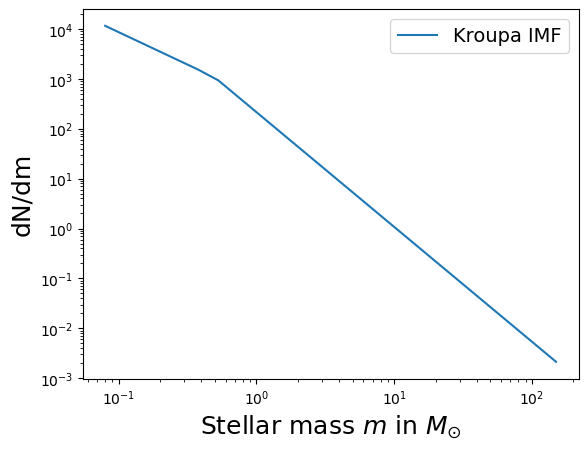

In [12]:
M_ecl=1000
x=np.linspace(0.08,150,1000)

i=0
Kroupa_IMF=np.array([])
while i<len(x):
    Kroupa_IMF=np.append(Kroupa_IMF, IMF(x[i],M_ecl, 150))
    i=i+1

plt.loglog(x, Kroupa_IMF, label='Kroupa IMF')
plt.xlabel(r'Stellar mass $m$ in $M_{\odot}$', size=18)
plt.ylabel(r'dN/dm', size=18)
plt.legend(fontsize=14)

## MLE for power laws

We are also initializing a maximum likelihood estimator (MLE) for power laws to check, that the slopes of the drawn samples are actually close to the theoretical values.\
This power law MLE is based on [Maschberger & Kroupa (2009)](https://academic.oup.com/mnras/article/395/2/931/1747409).

It returns the estimate and its standard error as: (estimate, error estimate)

In [13]:
def MLE_with_SE(data):

    Y=np.min(data)
    Z=np.max(data)
    T=np.sum(np.log(data))
    n=len(data)

    def Determinator(alpha_ML):  
        eq1 = -n/(1-alpha_ML)
        eq2 = n*(Z**(1-alpha_ML)*np.log(Z)-Y**(1-alpha_ML)*np.log(Y))/(Z**(1-alpha_ML)-Y**(1-alpha_ML))-T
        return eq1+eq2
        
    sol = root_scalar(Determinator, bracket=[-30.0, 0.999*30.0])
    slope = sol.root
    slope_unbiased=(n)/(n-2)*(slope-1)+1 ## According to Maschberger& Kroupa (2009)

    Fisher_information=n*(slope_unbiased/(1-slope_unbiased)**2+(Y**(1-slope_unbiased)*Z**(1-slope_unbiased)*((np.log(Z)-np.log(Y))**2))/(Z**(1-slope_unbiased)-Y**(1-slope_unbiased))**2)

    SE=np.sqrt(1/Fisher_information) ## standard error


    return slope_unbiased, SE

## Draw IMF samples

In [14]:
### Define a canonical IMF
alpha_1_model=0
alpha_2_model=0
alpha_3_model=0
M_over_H= 0 ## [Z] = [Z/Zsolar] (Metallicity)
M_ecl=50000 ## Mecl in Msolar
M_1=100 ## Mass of the most massive star in the cluster

m_i_array, M_i_array_canonical, totalmass, num_stars, k3, alpha_3, m_max_can = draw_imf_empirical(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
print('Mass of the most massive star in the cluster:', M_i_array_canonical[0] , 'solar masses')

m2_1= 98.21648989145116
Total mass of cluster: 49999.942405647256
Mass of the most massive star in the cluster: 99.99999999999852 solar masses


In [15]:
### Define a varying IMF
alpha_1_model='Z' 
alpha_2_model='Z'
alpha_3_model=2
M_over_H= 0 ## [Z] = [Z/Zsolar] (Metallicity)
M_ecl=50000 ## Mecl in Msolar
M_1=100 ## Mass of the most massive star in the cluster

m_i_array, M_i_array, totalmass, num_stars, k3, alpha_3, m_max = draw_imf_empirical(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
print('Mass of the most massive star in the cluster:', M_i_array[0] , 'solar masses')

## Determine the slopes of the IMF sample
print(r'The IMF slope for m < 0.5 Msolar is:',MLE_with_SE(M_i_array[M_i_array<0.5])[0], '+/-', MLE_with_SE(M_i_array[M_i_array<0.5])[1])
print(r'The IMF slope for 0.5 < m < 1 Msolar is:',MLE_with_SE(M_i_array[(M_i_array<1) & (M_i_array>0.5)])[0], '+/-', MLE_with_SE(M_i_array[(M_i_array<1) & (M_i_array>0.5)])[1])
print(r'The IMF slope for m > 1 Msolar is:',MLE_with_SE(M_i_array[M_i_array>1])[0], '+/-', MLE_with_SE(M_i_array[M_i_array>1])[1])
print(r'The input high-mass slope (m > 1 Msolar) of the drawn sample is:', alpha_3)

m2_1= 99.21603884059735
Total mass of cluster: 49999.96011625277
Mass of the most massive star in the cluster: 99.99999999999339 solar masses
The IMF slope for m < 0.5 Msolar is: 1.3000060382966505 +/- 0.0008968361875772106
The IMF slope for 0.5 < m < 1 Msolar is: 2.3001375181074897 +/- 0.0075369649102608955
The IMF slope for m > 1 Msolar is: 2.055152245174966 +/- 0.008037348007384091
The input high-mass slope (m > 1 Msolar) of the drawn sample is: 2.055124725896406


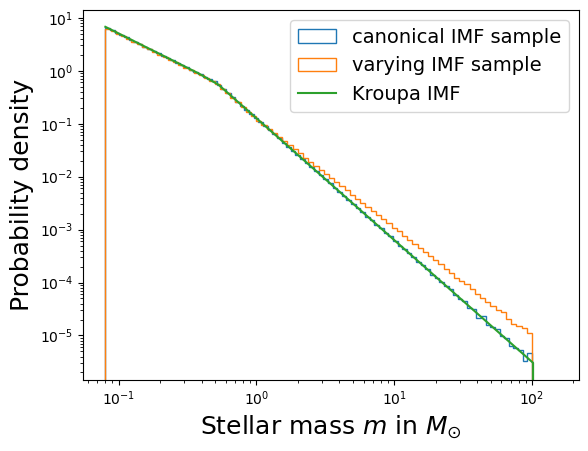

In [16]:
## Plot the samples
logbins=np.logspace(np.log10(np.min(M_i_array_canonical)),np.log10(np.max(M_i_array_canonical)),int(len(M_i_array_canonical)**(2/5)-1))
plt.hist(M_i_array_canonical, bins=logbins, density=True, label='canonical IMF sample', histtype='step')

logbins=np.logspace(np.log10(np.min(M_i_array)),np.log10(np.max(M_i_array)),int(len(M_i_array)**(2/5)-1))
plt.hist(M_i_array, bins=logbins, density=True, label='varying IMF sample', histtype='step')
plt.xscale('log')
plt.yscale('log')

x=np.linspace(0.08,150,1000)
i=0
Kroupa_IMF=np.array([])
while i<len(x):
    Kroupa_IMF=np.append(Kroupa_IMF, IMF(x[i], M_ecl, m_max_can)/len(M_i_array_canonical))
    i=i+1

plt.loglog(x, Kroupa_IMF, label='Kroupa IMF')
plt.xlabel(r'Stellar mass $m$ in $M_{\odot}$', size=18)
plt.ylabel(r'Probability density', size=18)
plt.legend(fontsize=14)

The drawn samples end at 100 solar masses instead of close to 150 solar masses, exactly as given as input.\
The code allows to give arbitrary inputs and return a sample of stars that per design follow the given IMF as close as possible while meeting the given boundary conditions of cluster mass and most massive stellar mass.

# Complete function

For easier application, the sampling function with all necessary sub-functions included is given below.

In [1]:
### IMF sampling function with most massive stellar mass as input. Can be used with empirical m_max-M_ecl relations.

### Needs mass of the embedded cluster (M_ecl), 
### the mass of the most massive star (M_1),
### the IMF model for the IMF powerlaw indices (alpha_1_model, alpha_2_model, alpha_3_model)
### and the metallicity of the cluster (M_over_H) as input

from scipy.optimize import root_scalar
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.integrate

def draw_imf_empirical(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
    M_str_L = 0.08  # star mass lower limit [solar mass]
    M_str_U = 150.0  # star mass upper limit [solar mass]
    M_turn = 0.5  # IMF power-index breaking mass [solar mass]
    M_turn2 = 1.  # IMF power-index breaking mass [solar mass]

    ## Necessary functions to draw stellar masses
    
    ####### Defining the IMF form
    
    ## In order to sample an IMF form needs to be chosen. Here, a Kroupa IMF is used.
    ## function_alpha_i_change gives the value alpha_i of the IMF slope.
    
    ### function alpha_1_change(alpha_1, alpha1_model, M_over_H) imported from galimf.py
    def function_alpha_1_change(alpha1_model, M_over_H):
        alpha_1 = 1.3
        if (alpha1_model == 0):
            return alpha_1
        elif (alpha1_model == 1):
            alpha_1_change = alpha_1 + 0.5 * M_over_H
            return alpha_1_change
        elif (alpha1_model == 'IGIMF2.5'):
            alpha_1_change = alpha_1 + 0.12 * M_over_H
            return alpha_1_change
        elif (alpha1_model == 'Z_MW'):
            alpha_1_change = alpha_1 + 79.4 * (10**M_over_H - 10**(-0.1)) * 0.0142
            return alpha_1_change
        elif (alpha1_model == 'Z'):
            alpha_1_change = alpha_1 + 63 * (10**M_over_H - 1) * 0.0142
            return alpha_1_change
        else:
            print('Invalid Input for alpha1 model')
            return
    
    ## Function to change alpha_2 depending on the model; imported from galimf.py
    def function_alpha_2_change(alpha2_model, M_over_H):
        alpha_2=2.3
        if (alpha2_model == 0):
            return alpha_2
        elif (alpha2_model == 1):
            alpha_2_change = alpha_2 + 0.5 * M_over_H
            return alpha_2_change
        elif (alpha2_model == 'Z_MW'):
            alpha_2_change = alpha_2 + 79.4 * (10**M_over_H - 10**(-0.1)) * 0.0142
            if M_over_H>1:
                print("Warning: Abnormally high gas metallicity leading to an unrealistic IMF shape according to the assumed variation law: alpha2_model == 'Z'. Please check your galaxy evolution settings or change to a different IMF variation assumption.")
            return alpha_2_change
        elif (alpha2_model == 'Z'):
            alpha_2_change = alpha_2 + 63 * (10**M_over_H - 1) * 0.0142
            if M_over_H>1:
                print("Warning: Abnormally high gas metallicity leading to an unrealistic IMF shape according to the assumed variation law: alpha2_model == 'Z'. Please check your galaxy evolution settings or change to a different IMF variation assumption.")
            return alpha_2_change
        elif (alpha2_model == 'IGIMF2.5'):
            alpha_2_change = alpha_2 + 0.12 * M_over_H
            return alpha_2_change
        elif (alpha2_model == 'R14'):
            alpha_2_change = 2.3 + 0.0572 * M_over_H
            return alpha_2_change
        else:
            print('Invalid input for alpha2 model')
            return
    
    ## Function to change alpha_3 depending on the model; imported from galimf.py
    def function_alpha_3_change(alpha3_model, M_ecl, M_over_H):
        ## M_ecl is the mass of the cluster
        ## M_over_H is the metallicity of the cluster, but apparently is in reality [Z]
        ## since the formula for model 2 is similar to the formula from Yan et al.(2021)
        ## where [Z] is used, I assume that M_over_H is actually [Z]
        ## alpha3_model is the model for the IMF power-index for M_turn2 < M < M_str_U
        if (alpha3_model == 0):
            default_alpha3 = 2.3
            # print("alpha_3 is set to be a constant: %s, as this is the default alpha_3 value for alpha3_model 0.\nFor more options regarding alpha_3 variation, please check file 'alpha3.py'" % (default_alpha3))
            return default_alpha3
        elif (alpha3_model == 1):
            rho = 10 ** (0.61 * math.log(M_ecl, 10) + 2.85)
            if rho < 9.5 * 10 ** 4:
                alpha_3_change = 2.3
            else:
                alpha_3_change = 1.86 - 0.43 * math.log(rho / 10 ** 6, 10)
            # print("Notification in file 'alpha3_model' uncompleted")
            if alpha_3_change < 0.5:
                print("IMF alpha_3 being", alpha_3_change, "out of the tested range from Marks et al. 2012.")
            return alpha_3_change
        elif (alpha3_model == 2):
            rho = 10 ** (0.61 * math.log(M_ecl, 10) + 2.85)
            x = -0.14 * M_over_H + 0.99 * math.log(rho / 10 ** 6, 10)
            if x < -0.87:
                alpha_3_change = 2.3
            else:
                alpha_3_change = -0.41 * x + 1.94
            # print("Notification in file 'alpha3_model' uncompleted")
            return alpha_3_change
        elif (alpha3_model == 'R14'):
            alpha_3_change = 2.3 + 0.0572 * M_over_H
            return alpha_3_change
        else:
            print('Invalid input for alpha_3 model')
            return alpha3_model
    
    ## IMF function*m with prefactor. Can be used to determine Masses M_i
    def model_IMF_m(m, alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3):
        M_str_L = 0.08  # star mass lower limit [solar mass]
        M_str_U = 150.0  # star mass upper limit [solar mass]
        M_turn = 0.5  # IMF power-index breaking mass [solar mass]
        M_turn2 = 1.  # IMF power-index breaking mass [solar mass]
    
        alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
        alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
        alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H) #IMF power-index for M_turn2 < M < M_str_U
    
        ## distinction between cases; IMF is three-part power-law
        if m < M_str_L:
            return 0
        if M_str_L < m < M_turn:
            ### becomes relevant when M_turn and M_turn_2 take different values
            #k1 = M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2)*k3 
            ### When M_turn=0.5 and M_turn2=1.0, k1 simplifies to:
            ###k1= 2.0*k3 ## No! This is only correct, when alpha_1=1.3, alpha_2=2.3 and alpha_3=2.3
            k1=M_turn**(alpha_1-alpha_2)*k3
    
            return k1 * m**(1-alpha_1)
        if M_turn < m < M_turn2:
            ### becomes relevant when M_turn and M_turn_2 take different values
            #k2 = M_turn2**(alpha_2-alpha_3)*k3 
            ### When M_turn=0.5 and M_turn2=1.0, k2 simplifies to:
            k2= 1.0*k3 ## k2=k3
            return k2 * m**(1-alpha_2)
        if M_turn2 < m < M_str_U:
            return k3*m**(1-alpha_3) ##
        if m > M_str_U:
            return 0

    ## M_max_finder case 1. Covers most cases with Mecl > 5 solar masses

    def find_m_max_empirical(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
        M_str_L = 0.08  # star mass lower limit [solar mass]
        M_str_U = 150.0  # star mass upper limit [solar mass]
        M_turn = 0.5  # IMF power-index breaking mass [solar mass]
        M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]
    
        alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
        alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
        alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U
    
        def Max(M_max):
            eq1 = M_max**(2-alpha_3)-(2-alpha_3)*M_1/(M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(M_max**(2-alpha_3)-M_turn2**(2-alpha_3))))
            eq2 = (M_max**(1-alpha_3)-(1-alpha_3)/(M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(M_max**(2-alpha_3)-M_turn2**(2-alpha_3)))))**((2-alpha_3)/(1-alpha_3)) 
            return eq1 - eq2
    
        ### If root-solving does not converge, give out some m_max value M_turn < m_max < M_turn2. Here, I chose 0.9.
        try:
            sol = root_scalar(Max, bracket=[M_turn2, 0.999999*M_str_U])
            M_max = sol.root
            return M_max
        except ValueError:
            return 0.9

    ## M_max_finder case 2
    
    def find_m_max_empirical_2(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
        M_str_L = 0.08  # star mass lower limit [solar mass]
        M_str_U = 150.0  # star mass upper limit [solar mass]
        M_turn = 0.5  # IMF power-index breaking mass [solar mass]
        M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]
    
        alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
        alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
        alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U
    
        def Max(M_max):
            eq1 = M_turn2**(2-alpha_2)+M_turn2**(alpha_3-alpha_2)*(2-alpha_2)/(2-alpha_3)*(M_max**(2-alpha_3)-M_turn2**(2-alpha_3))-(2-alpha_2)*M_1/(M_turn2**(alpha_2-alpha_3)*M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(M_max**(2-alpha_3)-M_turn2**(2-alpha_3))))
            eq2 = (M_turn2**(1-alpha_2)+M_turn2**(alpha_3-alpha_2)*(1-alpha_2)/(1-alpha_3)*(M_max**(1-alpha_3)-M_turn2**(1-alpha_3))-(1-alpha_2)/(M_turn2**(alpha_2-alpha_3)*M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(M_max**(2-alpha_3)-M_turn2**(2-alpha_3)))))**((2-alpha_2)/(1-alpha_2)) 
            return eq1 - eq2
        
        sol = root_scalar(Max, bracket=[M_turn2, 0.999999*M_str_U])
        M_max = sol.root
        return M_max


    ## M_max_finder case 3

    def find_m_max_empirical_3(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
        M_str_L = 0.08  # star mass lower limit [solar mass]
        M_str_U = 150.0  # star mass upper limit [solar mass]
        M_turn = 0.5  # IMF power-index breaking mass [solar mass]
        M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]
    
        alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
        alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
        alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U
    
        def Max(M_max):
            eq1 = M_max**(2-alpha_2)-(2-alpha_2)*M_1/(M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (M_max**(2-alpha_2) - M_turn**(2-alpha_2))))
            eq2 = (M_max**(1-alpha_2)-(1-alpha_2)/(M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (M_max**(2-alpha_2) - M_turn**(2-alpha_2)))))**((2-alpha_2)/(1-alpha_2)) 
            return eq1 - eq2
    
        ### If root-solving does not converge, give out some m_max value with m_max < M_turn2. Here, I chose 0.4.
        try:
            sol = root_scalar(Max, bracket=[M_turn, 0.999999*M_turn2])
            M_max = sol.root
            return M_max
        except ValueError:
            return 0.4

    ## M_max_finder case 4

    def find_m_max_empirical_4(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
        M_str_L = 0.08  # star mass lower limit [solar mass]
        M_str_U = 150.0  # star mass upper limit [solar mass]
        M_turn = 0.5  # IMF power-index breaking mass [solar mass]
        M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]
    
        alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
        alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
        alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U
    
        def Max(M_max):
            eq1 = M_turn**(2-alpha_1)+M_turn**(alpha_2-alpha_1)*(2-alpha_1)/(2-alpha_2)*(M_max**(2-alpha_2)-M_turn**(2-alpha_2))-(2-alpha_1)*M_1/(M_turn**(alpha_1-alpha_2)*M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (M_max**(2-alpha_2) - M_turn**(2-alpha_2))))
            eq2 = (M_turn**(1-alpha_1)+M_turn**(alpha_2-alpha_1)*(1-alpha_1)/(1-alpha_2)*(M_max**(1-alpha_2)-M_turn**(1-alpha_2))-(1-alpha_1)/(M_turn**(alpha_1-alpha_2)*M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (M_max**(2-alpha_2) - M_turn**(2-alpha_2)))))**((2-alpha_1)/(1-alpha_1)) 
            return eq1 - eq2
        
        sol = root_scalar(Max, bracket=[M_turn, 0.999999*M_turn2])
        M_max = sol.root
        return M_max


    ## M_max_finder case 5

    def find_m_max_empirical_5(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H):
        M_str_L = 0.08  # star mass lower limit [solar mass]
        M_str_U = 150.0  # star mass upper limit [solar mass]
        M_turn = 0.5  # IMF power-index breaking mass [solar mass]
        M_turn2 = 1.0  # IMF power-index breaking mass [solar mass]
    
        alpha_1 = function_alpha_1_change(alpha_1_model, M_over_H)  # IMF power-index for M_str_L < M < M_turn
        alpha_2 = function_alpha_2_change(alpha_2_model, M_over_H)  # IMF power-index for M_turn < M < M_turn2
        alpha_3 = function_alpha_3_change(alpha_3_model, M_ecl, M_over_H)  # IMF power-index for M_turn2 < M < M_str_U
    
        def Max(M_max):
            eq1 = M_max**(2-alpha_1)-(2-alpha_1)*M_1/(M_ecl * (2-alpha_1) / (M_max**(2-alpha_1) - M_str_L**(2-alpha_1)))
            eq2 = (M_max**(1-alpha_1)-(1-alpha_1)/(M_ecl * (2-alpha_1) / (M_max**(2-alpha_1) - M_str_L**(2-alpha_1))))**((2-alpha_1)/(1-alpha_1)) 
            return eq1 - eq2
    
        ### If root-solving does not converge, give out some m_max value with m_max < M_str_L to give out the final error message. Here, I chose 0.07
        try:
            sol = root_scalar(Max, bracket=[0.08+1e-15, 0.999999*M_turn])
            M_max = sol.root
            return M_max
        except ValueError:
            return 0.07

    ##################################################################################################

    ### Drawing from the IMF using the drawn cluster masses M_i

    ## Definition of alpha_1 and alpha_2
    alpha_1=function_alpha_1_change(alpha_1_model, M_over_H) #IMF power-index for M_str_L < M < M_turn
    alpha_2=function_alpha_2_change(alpha_2_model, M_over_H) #IMF power-index for M_turn < M < M_turn2

    ## alpha_3 is assumed to vary with metallicity and cluster mass
    alpha_3=function_alpha_3_change(alpha_3_model, M_ecl, M_over_H) #IMF power-index for M_turn2 < M < M_str_U

    ## Find m_max for a given M_ecl and M_1 by using root_scalar
    ## m_max=m_1 is the upper integration limit for the most massive star in the cluster
    ## It is NOT the mass of the most massive star in the cluster!

    ### m_i and m_i+1 are not the stellar masses, but only the upper and lower limits of the mass intervals
    ### from which the masses M_i are drawn

    # Determine m_max under the assumption M_turn2 < m2, m_max. 
    # This is always true for the canonical IMF if M_ecl > 5 but there may be special cases for other IMF forms or certain cutoffs. 
    m_max=find_m_max_empirical(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
    m_i=m_max
    
    
    ## Determine m_max by going through all cases
    if M_turn2 < m_max < M_str_U:
        k3=M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(m_max**(2-alpha_3)-M_turn2**(2-alpha_3)))
        k1=M_turn**(alpha_1-alpha_2)*k3
        k2=k3
        
        m_i_1=(m_i**(1-alpha_3)-(1-alpha_3)/(k3))**(1/(1-alpha_3)) #Case 1
        print('m2_1=',m_i_1)
    
        ## If m_2 < M_turn, recalculate m_max and m_2. Transition between case 1 and 2 is smooth, as both are equal, when m_2=M_turn2
        if M_turn < m_i_1 < M_turn2:
            m_max=find_m_max_empirical_2(M_ecl, M_1 , alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
            m_i=m_max
            k3=M_ecl/(M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + M_turn2**(alpha_2-alpha_3) / (2-alpha_2) * (M_turn2**(2-alpha_2) - M_turn**(2-alpha_2)) + 1/(2-alpha_3)*(m_max**(2-alpha_3)-M_turn2**(2-alpha_3)))
            k1=M_turn**(alpha_1-alpha_2)*k3
            k2=k3
            m_i_2=(M_turn2**(1-alpha_2)+k3/k2*(1-alpha_2)/(1-alpha_3)*(m_i**(1-alpha_3)-M_turn2**(1-alpha_3))-(1-alpha_2)/k2)**(1/(1-alpha_2)) #Case 2
            print('m2_2=',m_i_2)

    elif m_max < M_turn2:
        ## recalculate the m_max, if it is smaller than M_turn2. Transition between case 1 and 3 is smooth, as both are equal, when m_max=M_turn2
        m_max=find_m_max_empirical_3(M_ecl,M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
        m_i=m_max
        k2=M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (m_max**(2-alpha_2) - M_turn**(2-alpha_2)))
        m_i_3=(m_i**(1-alpha_2)-(1-alpha_2)/k2)**(1/(1-alpha_2))
        print('m2_3=',m_i_3)
        if M_turn < m_max < M_turn2:
            ## Check whether m_2 is larger or smaller than M_turn
            if M_turn < m_i_3 < M_turn2:
                k2=M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (m_max**(2-alpha_2) - M_turn**(2-alpha_2)))
                k1=M_turn**(alpha_1-alpha_2)*k2
                k3=k2
            ## If m_2 < M_turn, recalculate m_max and m_2. Transition between case 3 and 4 is smooth, as both are equal, when m_2=M_turn
            elif m_i_3 < M_turn:
                m_max=find_m_max_empirical_4(M_ecl,M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
                m_i=m_max
                k2=M_ecl/(M_turn**(alpha_1-alpha_2) / (2-alpha_1) * (M_turn**(2-alpha_1) - M_str_L**(2-alpha_1)) + 1 / (2-alpha_2) * (m_max**(2-alpha_2) - M_turn**(2-alpha_2)))
                k1=M_turn**(alpha_1-alpha_2)*k2
                k3=k2
                m_i_4=(M_turn**(1-alpha_1)+k2/k1*(1-alpha_1)/(1-alpha_2)*(m_i**(1-alpha_2)-M_turn**(1-alpha_2))-(1-alpha_1)/k1)**(1/(1-alpha_1))

                print('m2_4', m_i_4)
            
        ## when m_max is smaller than M_turn, the m_max has to be recalculated
        ## transition from case 3 to case 5 is smooth, as both are equal, when m_max=M_turn
        elif m_max < M_turn:
            m_max=find_m_max_empirical_5(M_ecl, M_1, alpha_1_model, alpha_2_model, alpha_3_model, M_over_H)
            m_i=m_max
            k1=M_ecl*(2-alpha_1)/(m_max**(2-alpha_1)-M_str_L**(2-alpha_1))
            k2=M_turn**(alpha_2-alpha_1)*k1
            k3=k2
            m_i_5=(m_i**(1-alpha_1)-(1-alpha_1)/k1)**(1/(1-alpha_1))
            print('m2_5=',m_i_5)
            ### if m_max< M_str_L it is not possible to draw stars
            if m_max < M_str_L:
                print('m_max < M_L. No stars can form')
                return None, None, None, None, None, None, None
    
        ### if m_max cannot be found something went wrong in the calculation of m_max
        else:
            print('m_max could not be found')
            return
        
    
    else:
        print('m_max could not be found')
        return

    ### draw all other stars with the conditions stated in supplementary document
    ### m_i_array is the array of all integration limits for the stars in the cluster
    m_i_array = np.array([])
    m_i_array=np.append(m_i_array,m_i)
    ### Array for all Masses M_i that are drawn with help of the integration limits m_i
    M_i_array = np.array([])
    ### Masses M_i are determined by integral from m_i+1 to m_i over m*IMF(m)

    ## k1 and k2 relate to k3 due to boundary conditions like this
    #k1 = M_turn2**(alpha_2-alpha_3) * M_turn**(alpha_1-alpha_2) * k3
    #k2 = M_turn2**(alpha_2-alpha_3) * k3

    ## When plugging in M_turn=0.5 and M_turn_2 = 1.0, k1 and k2 simplify to:
    ##k1=2*k3 ## This is only true in the canonical case!!

    #k1=M_turn**(alpha_1-alpha_2)*k3
    #k2=k3 ## This is only true, if M_turn2=1.0

    ## let loop run while the lower integration limit is larger than M_str_L
    while m_i > 0.08:

        ## General idea: m_i is known and I want to find m_i+1
        ## I can calculate m_i+1 with the conditions stated in the supplementary document
        ## that the integral between m_i and m_i+1 over the IMF is equal to 1.
        ## From the m_i+1, the mass M_i can be determined by integrating the IMF*m from m_i+1 to m_i

        if  M_turn2 < m_i < M_str_U:
            ## can either be case 1 or 2
            m_i_1=(m_i**(1-alpha_3)-(1-alpha_3)/(k3))**(1/(1-alpha_3)) #Case 1
            m_i_2=(M_turn2**(1-alpha_2)+k3/k2*(1-alpha_2)/(1-alpha_3)*(m_i**(1-alpha_3)-M_turn2**(1-alpha_3))-(1-alpha_2)/k2)**(1/(1-alpha_2)) #Case 2
            if M_turn2 < m_i_1 < m_i < M_str_U:
                m_i_array=np.append(m_i_array,m_i_1)
                ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
                M_i= (scipy.integrate.quad(model_IMF_m, m_i_1, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])
                M_i_array=np.append(M_i_array,M_i)
                m_i=m_i_1
            
            elif M_turn < m_i_2 < M_turn2:
                m_i_array=np.append(m_i_array,m_i_2)
                ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
                M_i= (scipy.integrate.quad(model_IMF_m, m_i_2, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])
                M_i_array=np.append(M_i_array,M_i)
                m_i=m_i_2
            else:
                print("Error")
                break
        elif M_turn < m_i < M_turn2:
            ## can either be case 3 or 4
            m_i_3=(m_i**(1-alpha_2)-(1-alpha_2)/k2)**(1/(1-alpha_2))
            m_i_4=(M_turn**(1-alpha_1)+k2/k1*(1-alpha_1)/(1-alpha_2)*(m_i**(1-alpha_2)-M_turn**(1-alpha_2))-(1-alpha_1)/k1)**(1/(1-alpha_1))
            
            if M_turn < m_i_3 < m_i < M_turn2:
                m_i_array=np.append(m_i_array,m_i_3)
                ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
                M_i= (scipy.integrate.quad(model_IMF_m, m_i_3, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])
                M_i_array=np.append(M_i_array,M_i)
                m_i=m_i_3
            elif M_str_L < m_i_4 < M_turn:
                m_i_array=np.append(m_i_array,m_i_4)
                ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
                M_i= (scipy.integrate.quad(model_IMF_m, m_i_4, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])
                M_i_array=np.append(M_i_array,M_i)
                m_i=m_i_4
            else:
                print("Error")
                break
        elif M_str_L < m_i < M_turn:
            ## can only be case 5
            m_i_5=(m_i**(1-alpha_1)-(1-alpha_1)/k1)**(1/(1-alpha_1))
            if M_str_L < m_i_5 < m_i < M_turn:
                m_i_array=np.append(m_i_array,m_i_5)
                ### with calculated m_i+1, the mass M_i can be determined by integrating the IMF from m_i+1 to m_i
                M_i= (scipy.integrate.quad(model_IMF_m, m_i_5, m_i, args=(alpha_1_model, alpha_2_model, alpha_3_model, M_ecl, M_over_H, k3))[0])
                M_i_array=np.append(M_i_array,M_i)
                m_i=m_i_5
            ## when m_i+1 is smaller than the lower mass limit, the loop stops
            elif m_i_5 < M_str_L:
                #print("All stars drawn")
                break
            else:
                print("Error")
                break
        else:
            print("Error")
            break

    totalmass = np.sum(M_i_array)
    num_stars = len(M_i_array)

    print('Total mass of cluster:', totalmass)

    return m_i_array, M_i_array, totalmass, num_stars, k3, alpha_3, m_max